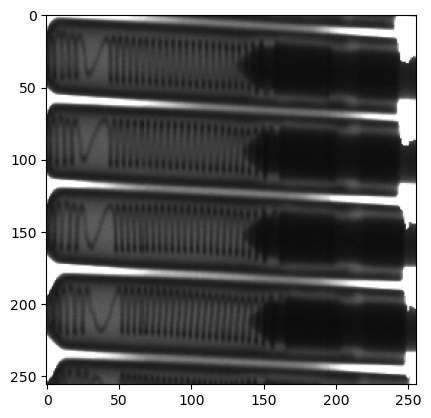

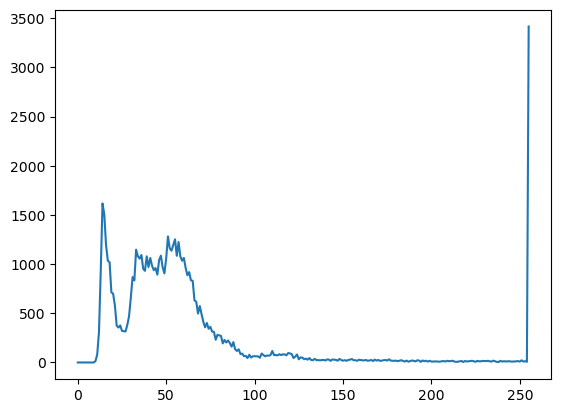

In [17]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image = cv2.imread("images/BOUGIES.png", cv2.IMREAD_GRAYSCALE)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.show()

# Visualizar histograma
hist = cv2.calcHist([image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

10
255


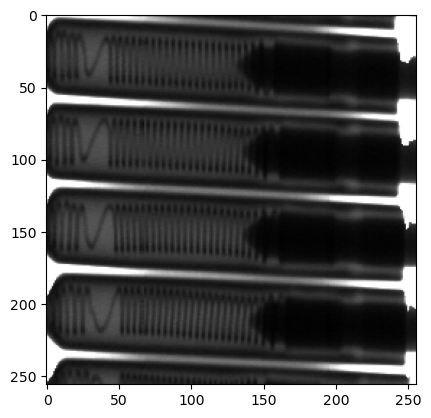

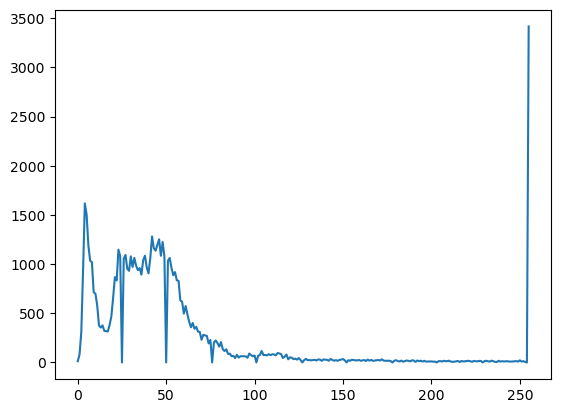

In [18]:
#Efectúe una expansión del contraste, visualice la imagen resultado y su histograma

from skimage import exposure

print(image.min())
print(image.max())
rescaled_img = exposure.rescale_intensity(image, in_range=(10,255), out_range=(0,255))

# Visualizar imagen
plt.imshow(rescaled_img, cmap="gray",  vmin=0, vmax=255)
plt.show()

# Visualizar histograma
rescaled_img = rescaled_img.astype(np.uint8)
hist = cv2.calcHist([rescaled_img],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

¿A qué se debe este resultado?
Hice la expansion con minimo (10) y maximo (255), y como los valores del 0 - 10 son muy oscuros, al truncarlos se aclaró la imagen.

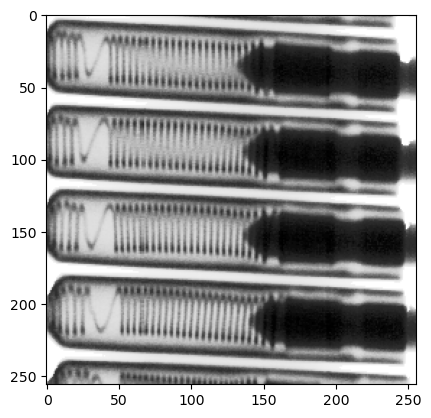

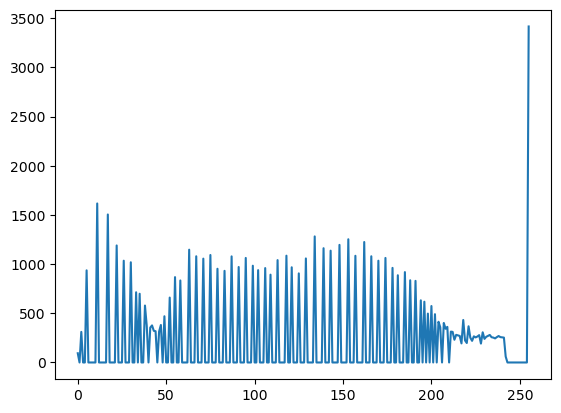

In [19]:
#Sobre la imagen original efectúe ahora una ecualización del histograma, visualice la imagen resultado y su histograma.
# Ecualizar el histograma
imagen_equ = cv2.equalizeHist(image)

# Visualizar imagen
plt.imshow(imagen_equ, cmap="gray",  vmin=0, vmax=255)
plt.show()

# Visualizar histograma
hist = cv2.calcHist([imagen_equ],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

Compare las imágenes resultado de la expansión (punto anterior) y de la ecualización (resultado actual), junto con sus histogramas. Comente sus observaciones.

En la expansión, no se marcó mucho el contraste, no hubo mucho cambio. Pero en la ecualizacion la diferencia si es bastante, al distribuir esos valores de grises es mucho mas notorio el contraste en la imagen. Los pixeles mas oscuros al reasignarse a colores mas claros, se ve mucho mas claro el detalle de la imagen

10


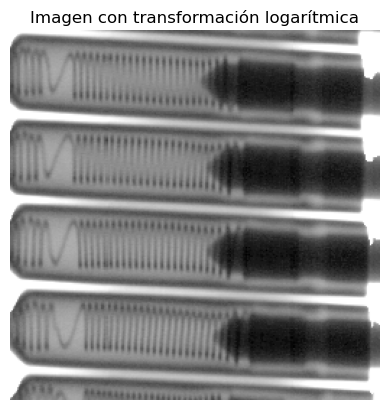

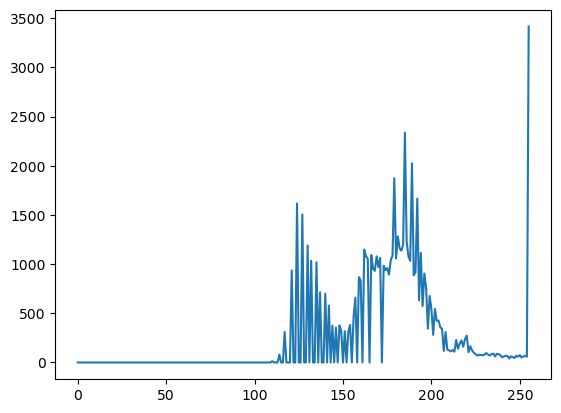

In [20]:
# Sobre la imagen original aplique ahora una transformación logarítmica y multiplique la imagen resultado por un valor constante de 46
# Transformación logarítmica

print(image.min())

# Convertir a float para evitar errores
image_float = image.astype(np.float32)

c = 46
image_log = c * np.log(1 + image_float)

# Volver a uint8
image_log = np.clip(image_log, 0, 255).astype(np.uint8)

# Visualizar imagen
plt.imshow(image_log, cmap='gray')
plt.title("Imagen con transformación logarítmica")
plt.axis('off')
plt.show()

# Histograma
hist = cv2.calcHist([image_log],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

¿Por qué es necesario multiplicar la imagen de salida por un factor? Visualice la imagen resultado y su histograma. ¿Cómo es el histograma resultado?

Es necesario multiplicarla por un factor, porque o si no los valores quedan muy bajos (generando una imagen muy oscura), como nuestra imagen es de 8 bits el valor maximo de un pixel es de 255 y en nuestra funcion logaritmica 255 + 1 quedarian los valores entre 0 y 6. De esa forma estariamos perdiendo todos los pixeles claros es por eso que toca multiplicarlo por una constante para que no quede una imagen tan oscura.

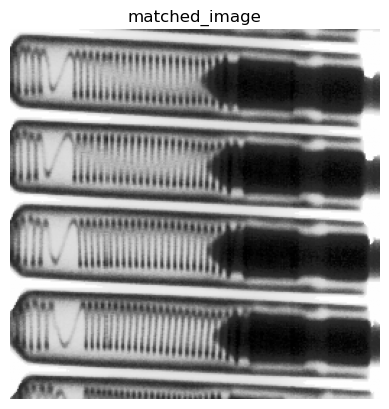

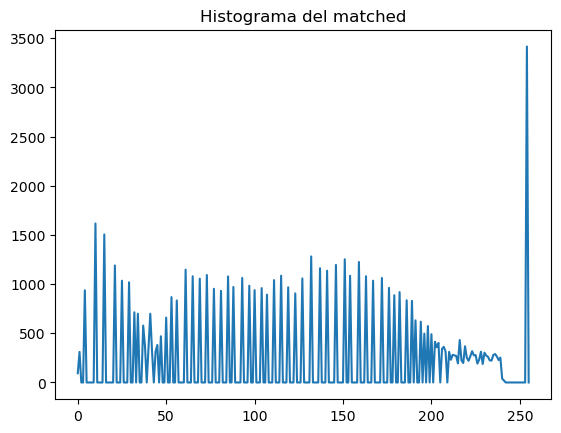

In [21]:
# Sobre la imagen original efectúe ahora una especificación de dos histogramas diferentes de entrada.
# Visualice la imagen resultado, los histogramas esperados y los histogramas obtenidos
import numpy as np
from skimage import exposure

# ------------------- Histograma de la imagen original -------------
# Ecualizar el histograma
imagen_equ_3 = cv2.equalizeHist(image)
hist = cv2.calcHist([imagen_equ_3],[0],None,[256],[0,256])


#Generamos la distribución acumulativa del histograma
cdf = np.cumsum(hist)
cdf = cdf / cdf[-1]

M, N = image.shape
L = 256
#Generamos un arreglo con valores aleatorios según la distribución
pixel_values  = np.interp(np.random.rand(N*M), cdf, range(0,L))
#Convertimos el arreglo en una imagen.
i_to_match= pixel_values.reshape(N,M).astype(np.uint8)
matched_image = exposure.match_histograms(image, i_to_match).astype(np.uint8)

# Visualizar imagen
plt.imshow(matched_image, cmap='gray', vmin=0, vmax=255)
plt.title("matched_image")
plt.axis('off')
plt.show()

# Histograma
hist = cv2.calcHist([matched_image],[0],None,[256],[0,256])
plt.plot(hist)
plt.title("Histograma del matched")
plt.show()